DataFrame Columns: Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='str')

 DecisionTree
Scores: [0.79220779 0.80250784 0.78987455 0.78181004 0.79077061]
Mean Accuracy: 0.7914341652662008

Comparison Table
          Model  Mean Accuracy       Std
0  DecisionTree       0.791434  0.006614


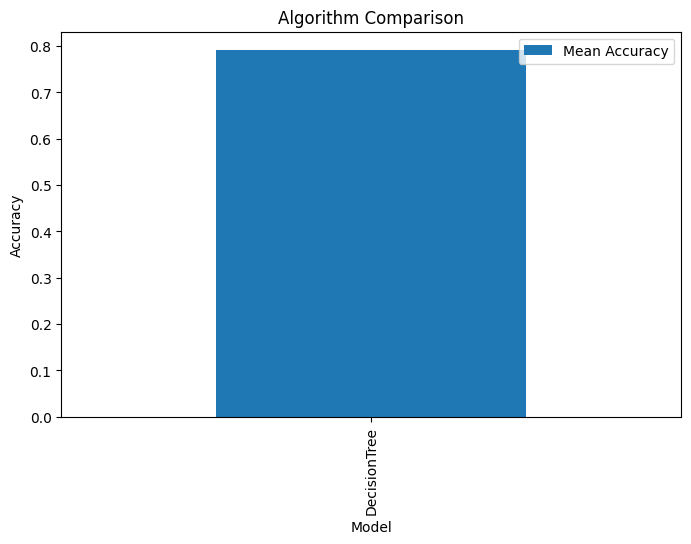


Best Model: DecisionTree

Accuracy: 0.8620689655172413
Precision: 0.8301056338028169
Recall: 0.8913043478260869
F1 Score: 0.8596171376481313

Confusion Matrix
[[982 193]
 [115 943]]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
from sklearn.utils import resample
from scipy.stats import ttest_rel

df=pd.read_csv("bank.csv")
print("DataFrame Columns:",df.columns)

df["deposit"]=df["deposit"].map({"yes":1,"no":0})

X=df.drop("deposit",axis=1)
y=df["deposit"]

num_cols=X.select_dtypes(include=np.number).columns
cat_cols=X.select_dtypes(exclude=np.number).columns

numeric_transfer=Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

categorical_transformer=Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor=ColumnTransformer([
    ("num",numeric_transfer,num_cols),
    ("cat",categorical_transformer,cat_cols)
])

Models={
    "DecisionTree":DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM":SVC()
}

cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
results={}

for name,model in Models.items():
    pipe=Pipeline([
        ("prep", preprocessor),
        ("model",model)
    ]) 
    scores=cross_val_score(
        pipe,
        X,
        y,cv=cv,
        scoring="accuracy"   
    )
    results[name]=scores
    print("\n",name)
    print("Scores:",scores)
    print("Mean Accuracy:",scores.mean())
    
    comparison=pd.DataFrame({
        "Model":results.keys(),
        "Mean Accuracy":[np.mean(v) for v in results.values()],
        "Std":[np.std(v) for v in results.values()] 
   })
    
    print("\nComparison Table")
    print(comparison)
    comparison.plot(
        x="Model",
        y="Mean Accuracy",
        kind="bar",
        figsize=(8,5)
    ) 
    plt.title("Algorithm Comparison")
    plt.ylabel("Accuracy")
    plt.show()
    
    best_model_name=max(results,key=lambda x: np.mean(results[x]))
    
    print("\nBest Model:",best_model_name)
    
    X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
    )
    
    
    final_model=Pipeline([
        ("prep",preprocessor),
        ("model",RandomForestClassifier(random_state=42))
    ])
    
    final_model.fit(X_train,y_train)
    y_pred=final_model.predict(X_test)
    
    print("\nAccuracy:",accuracy_score(y_test,y_pred))
    print("Precision:",precision_score(y_test,y_pred))
    print("Recall:",recall_score(y_test,y_pred))
    print("F1 Score:", f1_score(y_test,y_pred))
    
    print("\nConfusion Matrix")
    print(confusion_matrix(y_test,y_pred))
    
    bootstrap_scores=[]
    for i in range(100):
        X_boot,y_boot=resample(
            X,
            y,replace=True,
            random_state=i
        )
        model=Pipeline([
            ("prep",preprocessor),
            ("model",RandomForestClassifier(random_state=42))
        ])
        score=cross_val_score(
            model,
            X_boot,
            y_boot,
            cv=5,
            scoring="accuracy"
        ).mean()
        bootstrap_scores.append(score)
    print("\n Bootstrap Mean Accuracy:",np.mean(bootstrap_scores))
    print("Bootstrap Std:",np.std(bootstrap_scores))
    
    rf_scores=results["Random Forest"]
    lr_sscores=results["Logistic Regression"]
    
    t_stat,p_value=ttest_rel(
        rf_scores,
        lr_scores
    )
    print("\n Statistic:",t_stat)
    print("P value",p_value)
    if p_value<0.05:
        print("Significant difference found")
    else:
        print("No significant difference")
    
    